In [33]:


import os
import cv2
import glob as gb
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.10.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Parameters

In [18]:
# ==============================
# Local FER2013 dataset paths
# ==============================
project_root = r"C:\Emotion Reco\Emotion-Recognition"
train_path = os.path.join(project_root, "train")
test_path = os.path.join(project_root, "test")

if not os.path.isdir(train_path):
    raise FileNotFoundError(f"Training folder not found: {train_path}")
if not os.path.isdir(test_path):
    raise FileNotFoundError(f"Testing folder not found: {test_path}")

print("Train path:", train_path)
print("Test path:", test_path)
print("Training classes:", sorted(os.listdir(train_path)))
print("Testing classes:", sorted(os.listdir(test_path)))

# FER2013 images are originally 48x48 grayscale
height = 48
width = 48
color_channels = 1
image_size = (height, width, color_channels)

# FER2013 has 7 emotion classes
num_classes = 7

batch_size = 64
epochs = 50

# Preprocessing switches
USE_LIGHT_NOISE_REMOVAL = False
USE_HISTOGRAM_EQUALIZATION = False
USE_NORMALIZATION = True

# Full balanced class weights were too aggressive for this CNN.
# Keep this False for best accuracy; turn True only if recall on minority classes matters more.
USE_CLASS_WEIGHTS = False
USE_SOFT_CLASS_WEIGHTS = True


Train path: C:\Emotion Reco\Emotion-Recognition\train
Test path: C:\Emotion Reco\Emotion-Recognition\test
Training classes: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Testing classes: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [19]:
def preprocess_image(file_path):
    # Read image as grayscale because FER2013 is grayscale
    image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    # 1. Image Resizing
    image = cv2.resize(image, (width, height))

    # 2. Light Noise Removal
    if USE_LIGHT_NOISE_REMOVAL:
        image = cv2.GaussianBlur(image, (3, 3), 0)

    # 3. Histogram Equalization
    if USE_HISTOGRAM_EQUALIZATION:
        image = cv2.equalizeHist(image)

    # 4. Normalization
    image = image.astype("float32")
    if USE_NORMALIZATION:
        image = image / 255.0

    # Add channel dimension: (48, 48) -> (48, 48, 1)
    image = np.expand_dims(image, axis=-1)

    return image


def read_data_from_folder(folder_path, desc="Loading Data"):
    images = []
    labels = []

    class_folders = sorted(os.listdir(folder_path))

    for folder in class_folders:
        class_path = os.path.join(folder_path, folder)

        if not os.path.isdir(class_path):
            continue

        # Accept common image extensions
        files = []
        for ext in ["*.jpg", "*.jpeg", "*.png"]:
            files.extend(gb.glob(os.path.join(class_path, ext)))

        for file in tqdm(files, desc=f"{desc} - {folder}"):
            image = preprocess_image(file)

            if image is not None:
                images.append(image)
                labels.append(folder)

    return np.array(images), np.array(labels)


x_train, y_train = read_data_from_folder(train_path, desc="Training")
x_test, y_test = read_data_from_folder(test_path, desc="Testing")

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Testing - surprised: 100%|██████████| 831/831 [00:00<00:00, 4542.28it/s]

x_train: (28709, 48, 48, 1)
x_test: (7178, 48, 48, 1)
y_train: (28709,)
y_test: (7178,)


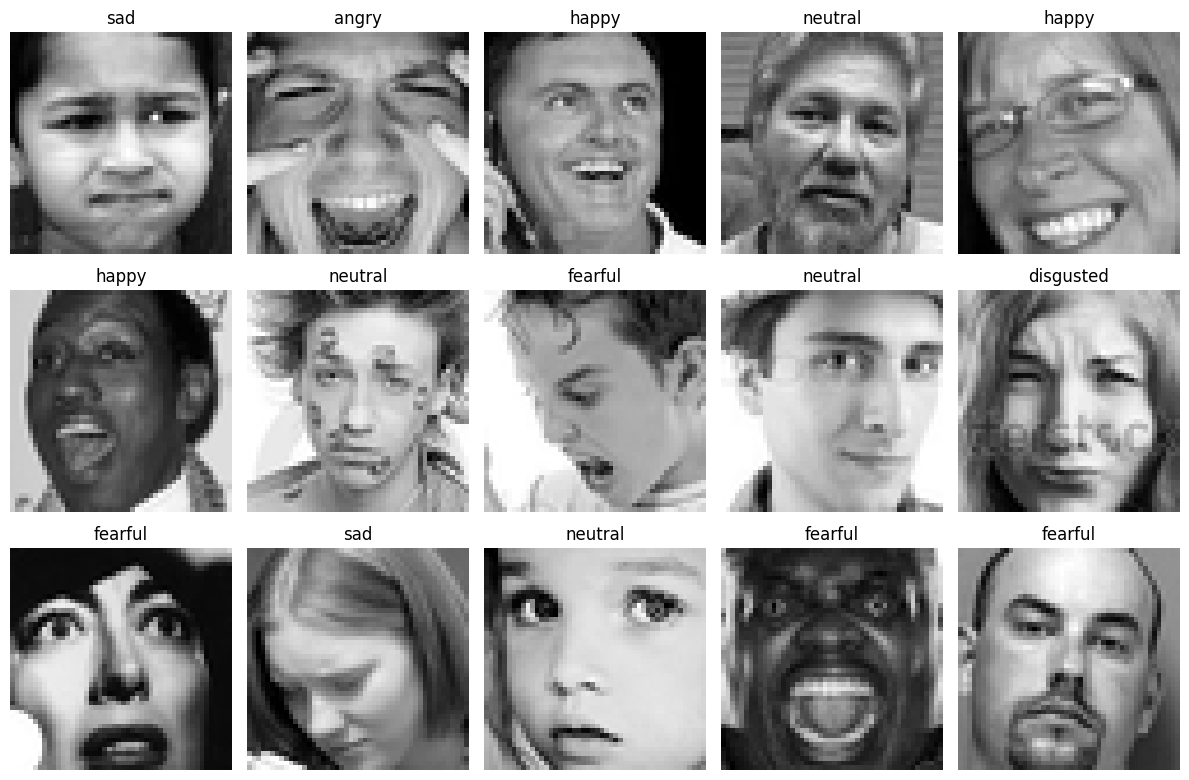

In [20]:
def visualize_data(images, labels, rows=3, cols=5):
    plt.figure(figsize=(12, 8))

    random_indexes = np.random.randint(0, len(images), rows * cols)

    for n, i in enumerate(random_indexes):
        plt.subplot(rows, cols, n + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.axis("off")
        plt.title(labels[i])

    plt.tight_layout()
    plt.show()


visualize_data(x_train, y_train)


## 8. Check Class Imbalance

Training class distribution:
angry: 3995
disgusted: 436
fearful: 4097
happy: 7215
neutral: 4965
sad: 4830
surprised: 3171


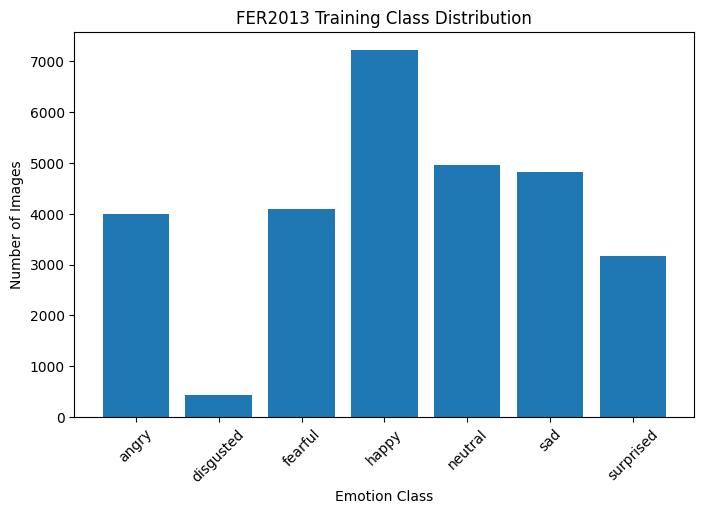

In [21]:
class_counts = Counter(y_train)

print("Training class distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("FER2013 Training Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()


## 9. Label Encoding

The labels are text, like `happy`, `sad`, and `angry`.

The CNN needs numerical labels, so we convert them to numbers, then to one-hot vectors.


In [22]:
label_encoder = LabelEncoder()

y_train_int = label_encoder.fit_transform(y_train)
y_test_int = label_encoder.transform(y_test)

class_names = list(label_encoder.classes_)
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

y_train_encoded = to_categorical(y_train_int, num_classes=num_classes)
y_test_encoded = to_categorical(y_test_int, num_classes=num_classes)

x_train_split, x_val, y_train_split_encoded, y_val_encoded, y_train_split_int, y_val_int = train_test_split(
    x_train,
    y_train_encoded,
    y_train_int,
    test_size=0.2,
    random_state=42,
    stratify=y_train_int
)

print("y_train_encoded:", y_train_encoded.shape)
print("y_test_encoded:", y_test_encoded.shape)
print("x_train_split:", x_train_split.shape)
print("x_val:", x_val.shape)
print("Training split class distribution:")
for class_index, count in sorted(Counter(y_train_split_int).items()):
    print(f"{class_names[class_index]}: {count}")
print("Validation split class distribution:")
for class_index, count in sorted(Counter(y_val_int).items()):
    print(f"{class_names[class_index]}: {count}")


Classes: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Number of classes: 7
y_train_encoded: (28709, 7)
y_test_encoded: (7178, 7)
x_train_split: (22967, 48, 48, 1)
x_val: (5742, 48, 48, 1)
Training split class distribution:
angry: 3196
disgusted: 349
fearful: 3277
happy: 5772
neutral: 3972
sad: 3864
surprised: 2537
Validation split class distribution:
angry: 799
disgusted: 87
fearful: 820
happy: 1443
neutral: 993
sad: 966
surprised: 634


## 10. Class Weighting

**Purpose:** Solve class imbalance during training.

Minority classes, such as `disgusted`, get higher weight, so the model does not ignore them.


In [23]:
balanced_class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_split_int),
    y=y_train_split_int
)

balanced_class_weights = dict(enumerate(balanced_class_weight_values))
soft_class_weights = {
    class_index: min(float(np.sqrt(weight)), 3.0)
    for class_index, weight in balanced_class_weights.items()
}

class_weights = soft_class_weights if USE_SOFT_CLASS_WEIGHTS else balanced_class_weights
fit_class_weights = class_weights if USE_CLASS_WEIGHTS else None

print("Balanced class weights:")
for class_index, weight in balanced_class_weights.items():
    print(f"{class_names[class_index]}: {weight:.4f}")

print()
print("Soft/capped class weights used if USE_CLASS_WEIGHTS=True:")
for class_index, weight in soft_class_weights.items():
    print(f"{class_names[class_index]}: {weight:.4f}")

print()
print("Class weights enabled:", USE_CLASS_WEIGHTS)


Balanced class weights:
angry: 1.0266
disgusted: 9.4011
fearful: 1.0012
happy: 0.5684
neutral: 0.8260
sad: 0.8491
surprised: 1.2933

Soft/capped class weights used if USE_CLASS_WEIGHTS=True:
angry: 1.0132
disgusted: 3.0000
fearful: 1.0006
happy: 0.7539
neutral: 0.9089
sad: 0.9215
surprised: 1.1372

Class weights enabled: False


## 11. Data Augmentation

**Purpose:** Make the training data more varied.

We apply augmentation only to the training data, not the test data.

Techniques used:
- Rotation
- Width shift
- Height shift
- Zoom
- Horizontal flip
- Brightness variation


In [24]:
train_datagen = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    horizontal_flip=True
)

train_generator = train_datagen.flow(
    x_train_split,
    y_train_split_encoded,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_data = (x_val, y_val_encoded)


## 12. Show Augmented Images

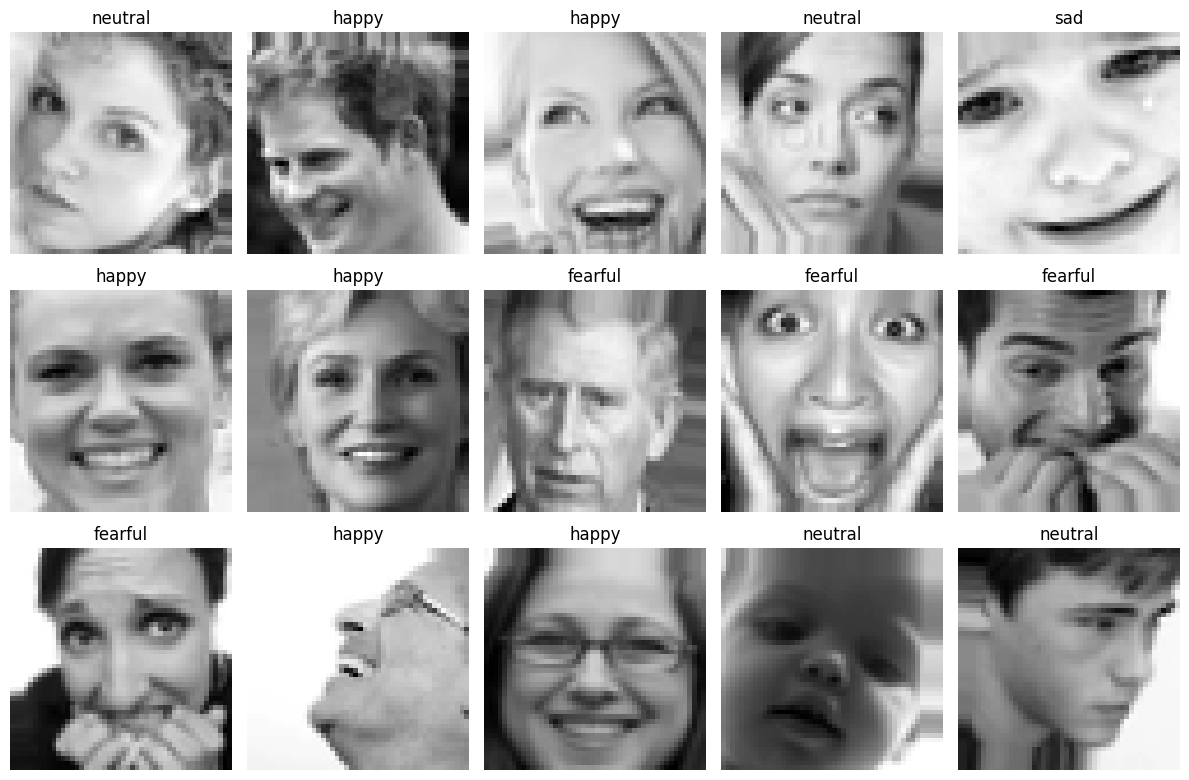

In [25]:
sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(sample_images[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(class_names[np.argmax(sample_labels[i])])

plt.tight_layout()
plt.show()


## 13. Build Custom CNN From Scratch

This is the Lab9-style CNN model, adjusted for FER2013 emotion recognition.


In [26]:
def create_custom_cnn(image_size, num_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=image_size),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),
        layers.Dense(256, activation="relu", kernel_initializer="he_normal"),
        layers.Dropout(0.50),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()
    return model


single_model = create_custom_cnn(image_size, num_classes)


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 48, 48, 32)        320       
                                                                 
 conv2d_4 (Conv2D)           (None, 48, 48, 32)        9248      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 24, 24, 32)       0         
 2D)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 24, 24, 32)        0         
                                                                 
 conv2d_5 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 conv2d_6 (Conv2D)           (None, 24, 24, 64)        36928     
                                                      

In [27]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=12,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_fer2013_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history = single_model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_data,
    class_weight=fit_class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/50
359/359 [==============================] - ETA: 0s - loss: 1.8467 - accuracy: 0.2403
Epoch 1: val_accuracy improved from -inf to 0.25131, saving model to best_fer2013_cnn_model.h5
359/359 [==============================] - 9s 22ms/step - loss: 1.8467 - accuracy: 0.2403 - val_loss: 1.8043 - val_accuracy: 0.2513 - lr: 5.0000e-04
Epoch 2/50
357/359 [============================>.] - ETA: 0s - loss: 1.7519 - accuracy: 0.2884
Epoch 2: val_accuracy improved from 0.25131 to 0.37060, saving model to best_fer2013_cnn_model.h5
359/359 [==============================] - 7s 21ms/step - loss: 1.7511 - accuracy: 0.2889 - val_loss: 1.6029 - val_accuracy: 0.3706 - lr: 5.0000e-04
Epoch 3/50
358/359 [============================>.] - ETA: 0s - loss: 1.6245 - accuracy: 0.3596
Epoch 3: val_accuracy improved from 0.37060 to 0.43417, saving model to best_fer2013_cnn_model.h5
359/359 [==============================] - 7s 19ms/step - loss: 1.6241 - accuracy: 0.3598 - val_loss: 1.4686 - val_accuracy

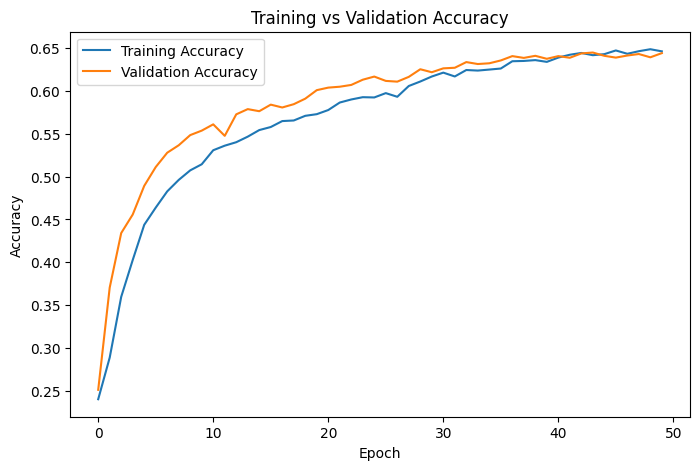

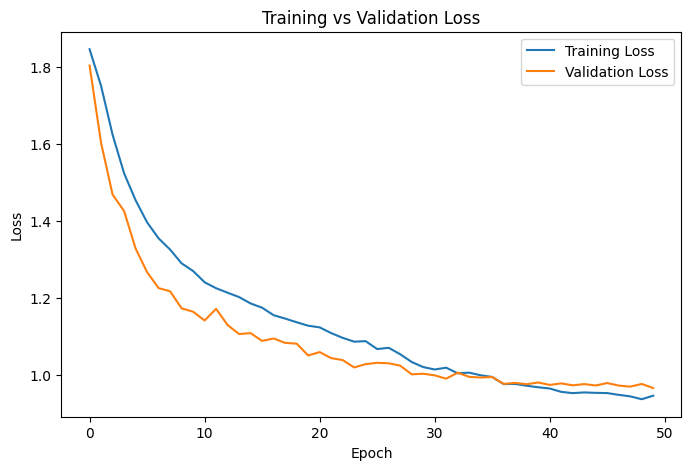

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
best_model_path = "best_fer2013_cnn_model.h5"
if os.path.exists(best_model_path):
    print("Loading best checkpoint:", best_model_path)
    evaluation_model = tf.keras.models.load_model(best_model_path)
else:
    print("Best checkpoint not found; using current in-memory model.")
    evaluation_model = single_model

predictions = evaluation_model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test_int

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print()
print("Predicted class distribution:")
for class_index, count in sorted(Counter(y_pred).items()):
    print(f"{class_names[class_index]}: {count}")


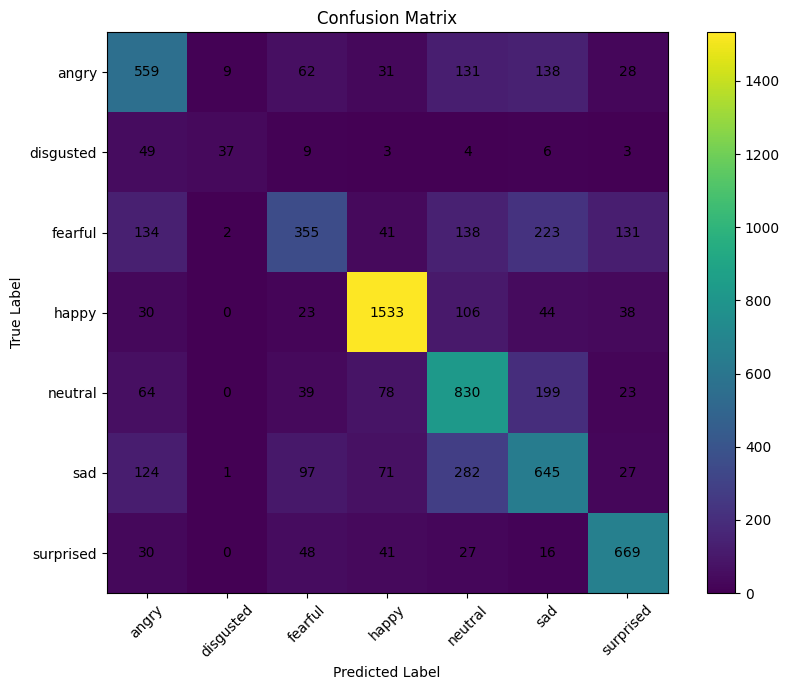

In [30]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


In [31]:
x_train_rgb = np.repeat(x_train, 3, axis=-1)
x_test_rgb = np.repeat(x_test, 3, axis=-1)

transfer_image_size = (height, width, 3)

print("x_train_rgb:", x_train_rgb.shape)
print("x_test_rgb:", x_test_rgb.shape)


x_train_rgb: (28709, 48, 48, 3)
x_test_rgb: (7178, 48, 48, 3)


In [ ]:
def create_mobilev3small(image_size, num_classes):
    base_model = tf.keras.applications.MobileNetV3Small(
        include_top=False,
        weights="imagenet",
        input_shape=image_size
    )

    # Freeze most layers first
    for layer in base_model.layers:
        layer.trainable = False

    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()
    return model


# mobile_model = create_mobilev3small(transfer_image_size, num_classes)
# mobile_history = mobile_model.fit(
#     train_datagen.flow(x_train_rgb, y_train_encoded, batch_size=batch_size, subset="training", shuffle=True, seed=42),
#     epochs=epochs,
#     validation_data=validation_datagen.flow(x_train_rgb, y_train_encoded, batch_size=batch_size, subset="validation", shuffle=False, seed=42),
#     class_weight=class_weights,
#     callbacks=[early_stop]
# )
